# Basics: what is parameter estimation?

**FQCP 2026 · Bayesian parameter estimation for gravitational-wave sources**

> Google Colab worksheet for early-stage graduate students. Run from top to
> bottom; **Extension** sections may be skipped live.

## Goal

Parameter estimation (PE) means learning about unknown parameters from data. By
the end of this notebook you should be able to distinguish the four pieces of
Bayes' theorem, calculate a small posterior by hand, and explain why a noise PSD
appears in a gravitational-wave likelihood.

We will follow the teaching sequence used in the NZ Bilby CBC workshop:

1. write a signal model;
2. choose priors;
3. write a likelihood from a noise assumption;
4. calculate a posterior on a grid;
5. inspect marginals and posterior predictions;
6. replace white noise by a gravitational-wave-style PSD-weighted likelihood.

Bayes' theorem is

$$
p(\theta\mid d,M)=\frac{p(d\mid\theta,M)\,p(\theta\mid M)}{p(d\mid M)}
=\frac{\mathcal L(d\mid\theta)\,\pi(\theta)}{\mathcal Z}.
$$

| Quantity | Meaning | Depends on |
| --- | --- | --- |
| prior $\pi(\theta)$ | what parameter values the model allows before these data | assumptions and previous information |
| likelihood $\mathcal L(d\mid\theta)$ | how compatible the observed data are with a proposed parameter value | signal and noise models |
| posterior $p(\theta\mid d)$ | updated uncertainty after conditioning on the observed data | prior × likelihood |
| evidence $\mathcal Z=p(d\mid M)$ | average likelihood across the prior for one complete model | likelihood and prior volume |

The evidence normalises the posterior and can compare complete models through a
Bayes factor. It is not a parameter estimate or a generic goodness-of-fit score.

### A posterior is more than one best-fit template

A maximum-likelihood template answers “which tested parameter value fits best?”
A posterior also exposes uncertainty, degeneracies, multiple modes, and prior
sensitivity, and it can be propagated into predictions or population analyses.

This is not the same as saying that frequentist inference only produces point
estimates: confidence regions, profile likelihoods, and sampling distributions
also quantify uncertainty. The key distinction is interpretation. A Bayesian
credible interval assigns probability to parameters conditional on the model
and observed data; a frequentist confidence procedure is calibrated over
repeated hypothetical datasets.

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import HTML, display
from matplotlib.animation import FuncAnimation

IN_COLAB = "COLAB_RELEASE_TAG" in os.environ
rng = np.random.default_rng(20260817)
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["animation.html"] = "jshtml"
print("Running in Colab:", IN_COLAB)

Running in Colab: False


## 1. Data and a signal model

Assume $d_i=m t_i+c+n_i$ and independent Gaussian noise $n_i\sim\mathcal N(0,\sigma^2)$. Every likelihood statement is conditional on assumptions like these.

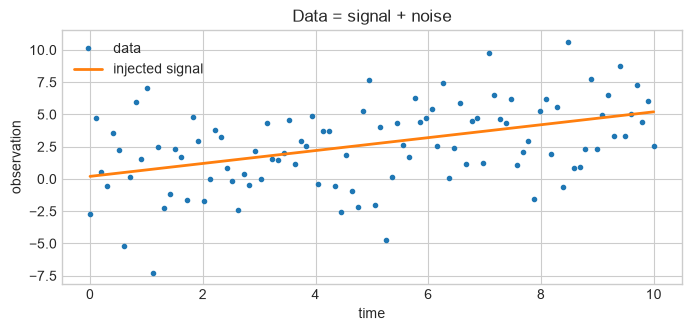

In [2]:
true_parameters = {"m": 0.5, "c": 0.2}
sigma = 3.0
time = np.linspace(0, 10, 100)


def signal_model(time, m, c):
    return m * time + c


data = signal_model(time, **true_parameters) + rng.normal(0, sigma, time.size)
fig, ax = plt.subplots(figsize=(8, 3.3))
ax.plot(time, data, "o", ms=3, label="data")
ax.plot(time, signal_model(time, **true_parameters), lw=2, label="injected signal")
ax.set(xlabel="time", ylabel="observation", title="Data = signal + noise")
ax.legend()
plt.show()

## 2. Priors and prior predictive checks

Take $m\sim\mathrm{Uniform}(0,1.5)$ and $c\sim\mathrm{Uniform}(-5,5)$. A prior is part of the model, not an afterthought. Drawing curves from it checks whether the model can plausibly describe the data before inference.

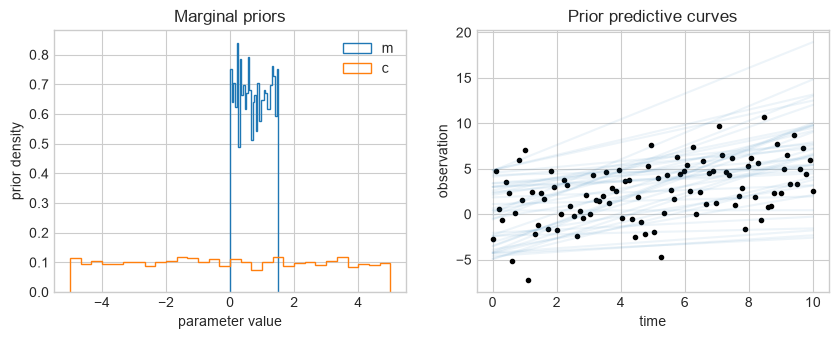

In [3]:
n_prior = 2500
prior_m = rng.uniform(0, 1.5, n_prior)
prior_c = rng.uniform(-5, 5, n_prior)
fig, axes = plt.subplots(1, 2, figsize=(10, 3.4))
axes[0].hist(prior_m, bins=30, density=True, histtype="step", label="m")
axes[0].hist(prior_c, bins=30, density=True, histtype="step", label="c")
axes[0].set(xlabel="parameter value", ylabel="prior density", title="Marginal priors")
axes[0].legend()
axes[1].plot(time, data, "o", ms=3, color="k")
for m, c in zip(prior_m[:40], prior_c[:40]):
    axes[1].plot(time, signal_model(time, m, c), color="C0", alpha=0.08)
axes[1].set(xlabel="time", ylabel="observation", title="Prior predictive curves")
plt.show()

## 3. Gaussian likelihood

$$
\log\mathcal L(d\mid m,c)=-\frac12\sum_i\left[
\frac{(d_i-mt_i-c)^2}{\sigma^2}+\log(2\pi\sigma^2)\right].
$$

Changing the assumed noise scale changes the width of the posterior. If the noise model is wrong, a mathematically correct sampler still gives a misleading answer.

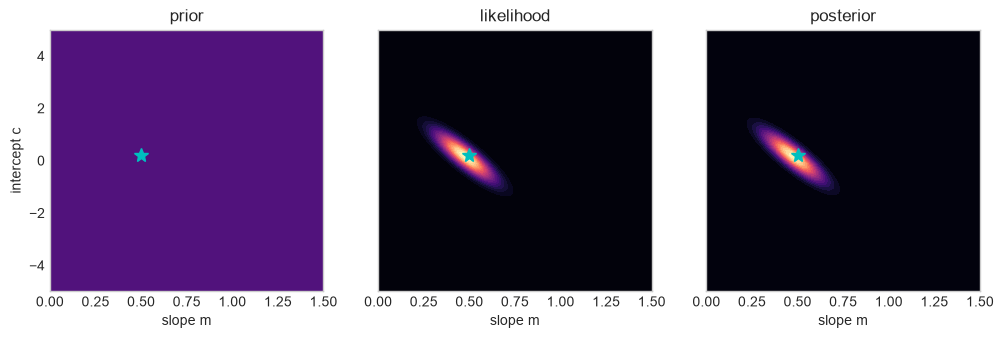

In [4]:
def log_likelihood(m, c):
    residual = data - signal_model(time, m, c)
    return -0.5 * np.sum((residual / sigma) ** 2 + np.log(2 * np.pi * sigma**2))


m_grid = np.linspace(0, 1.5, 141)
c_grid = np.linspace(-5, 5, 161)
M, C = np.meshgrid(m_grid, c_grid, indexing="ij")
logL = np.array([[log_likelihood(m, c) for c in c_grid] for m in m_grid])
log_prior = np.zeros_like(logL)  # constant inside this finite grid
log_posterior = logL + log_prior
posterior = np.exp(log_posterior - log_posterior.max())
posterior /= np.trapezoid(np.trapezoid(posterior, c_grid, axis=1), m_grid)

fig, axes = plt.subplots(1, 3, figsize=(12, 3.4), sharex=True, sharey=True)
for ax, values, title in zip(
    axes,
    [np.exp(log_prior), np.exp(logL - logL.max()), posterior],
    ["prior", "likelihood", "posterior"],
):
    image = ax.contourf(m_grid, c_grid, values.T, levels=24, cmap="magma")
    ax.plot(true_parameters["m"], true_parameters["c"], "c*", ms=10)
    ax.set(title=title, xlabel="slope m")
axes[0].set_ylabel("intercept c")
plt.show()

The posterior is a ridge: increasing the slope can be compensated by decreasing the intercept. Marginalisation integrates over the other parameter; it is not the same as holding it at a best-fit value.

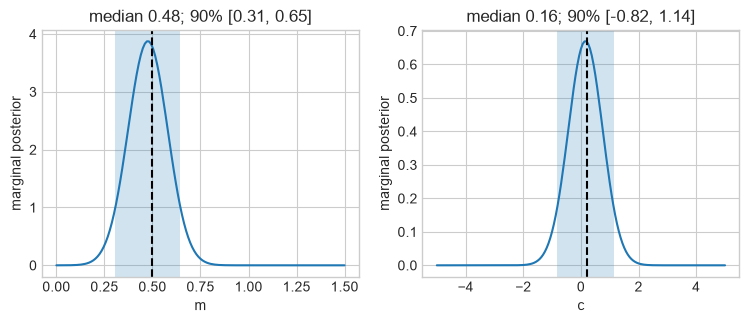

In [5]:
p_m = np.trapezoid(posterior, c_grid, axis=1)
p_c = np.trapezoid(posterior, m_grid, axis=0)


def interval(grid, density):
    cdf = np.r_[0, np.cumsum((density[:-1] + density[1:]) * np.diff(grid) / 2)]
    cdf /= cdf[-1]
    return np.interp([0.05, 0.5, 0.95], cdf, grid)


fig, axes = plt.subplots(1, 2, figsize=(9, 3.2))
for ax, grid, density, name, truth in zip(
    axes, [m_grid, c_grid], [p_m, p_c], ["m", "c"], true_parameters.values()
):
    q = interval(grid, density)
    ax.plot(grid, density)
    ax.axvline(truth, color="k", ls="--")
    ax.axvspan(q[0], q[2], alpha=0.2)
    ax.set(
        xlabel=name,
        ylabel="marginal posterior",
        title=f"median {q[1]:.2f}; 90% [{q[0]:.2f}, {q[2]:.2f}]",
    )
plt.show()

### What does the evidence do?

For a model $M$, the evidence averages the likelihood over its **normalised**
prior,

$$
\mathcal Z_M=\int \mathcal L(d\mid\theta,M)\,\pi(\theta\mid M)\,d\theta.
$$

The next cell compares a line with free slope and intercept ($M_1$) against a
line forced through zero ($M_0$). A model does not win merely because its best
fit is higher: extra prior volume that fits poorly reduces its evidence. This
is the Bayesian form of an Occam penalty, and it also means Bayes factors must
be reported with their priors.

In [6]:
def log_trapezoid_exp(log_values, grid, axis=-1):
    """Stable log of the trapezoidal integral of exp(log_values)."""
    reference = np.max(log_values)
    integral = np.trapezoid(np.exp(log_values - reference), grid, axis=axis)
    return reference + np.log(integral)


# M1: m and c are both free with a uniform prior on the plotted rectangle.
log_z_free_intercept = log_trapezoid_exp(
    np.array([log_trapezoid_exp(logL[row], c_grid) for row in range(len(m_grid))]),
    m_grid,
) - np.log((m_grid[-1] - m_grid[0]) * (c_grid[-1] - c_grid[0]))

# M0: c=0 exactly and only m is free.
logL_zero_intercept = np.array([log_likelihood(m, 0.0) for m in m_grid])
log_z_zero_intercept = log_trapezoid_exp(logL_zero_intercept, m_grid) - np.log(
    m_grid[-1] - m_grid[0]
)

log_bayes_factor = log_z_free_intercept - log_z_zero_intercept
print(f"log Z (free intercept): {log_z_free_intercept:.2f}")
print(f"log Z (zero intercept): {log_z_zero_intercept:.2f}")
print(f"log Bayes factor, free/zero: {log_bayes_factor:.2f}")

log Z (free intercept): -253.01
log Z (zero intercept): -251.14
log Bayes factor, free/zero: -1.87


### Fast animation: information accumulates

Each frame uses a longer prefix of the same dataset. The posterior does not have to shrink monotonically for every noise realisation, but its typical scale contracts as information accumulates.

In [7]:
model_cube = M[:, :, None] * time[None, None, :] + C[:, :, None]
cumulative_sse = np.cumsum((data[None, None, :] - model_cube) ** 2, axis=2)
frame_sizes = np.arange(8, time.size + 1, 6)
slope_densities = []
for n_used in frame_sizes:
    frame_logp = -0.5 * cumulative_sse[:, :, n_used - 1] / sigma**2
    frame_p = np.exp(frame_logp - frame_logp.max())
    marginal = np.trapezoid(frame_p, c_grid, axis=1)
    slope_densities.append(marginal / np.trapezoid(marginal, m_grid))
fig, ax = plt.subplots(figsize=(7, 3.2))
(line,) = ax.plot([], [], color="C3")
ax.axvline(true_parameters["m"], color="k", ls="--")
ax.set(
    xlim=(m_grid.min(), m_grid.max()),
    ylim=(0, 1.1 * np.max(slope_densities)),
    xlabel="slope m",
    ylabel="posterior density",
)


def animate_learning(i):
    line.set_data(m_grid, slope_densities[i])
    ax.set_title(f"posterior after {frame_sizes[i]} observations")
    return (line,)


learning_animation = FuncAnimation(
    fig, animate_learning, frames=len(frame_sizes), interval=150
)
plt.close(fig)
display(HTML(learning_animation.to_jshtml()))

## 4. Posterior predictive check

Draw parameter pairs from the posterior and map each through the signal model. This asks whether the inferred model can reproduce data like those observed.

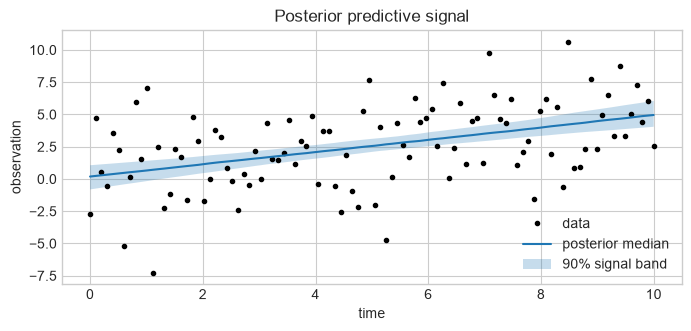

In [8]:
weights = (posterior / posterior.sum()).ravel()
choices = rng.choice(weights.size, size=250, replace=True, p=weights)
m_samples = M.ravel()[choices]
c_samples = C.ravel()[choices]
predictions = np.array([signal_model(time, m, c) for m, c in zip(m_samples, c_samples)])
low, median, high = np.quantile(predictions, [0.05, 0.5, 0.95], axis=0)
fig, ax = plt.subplots(figsize=(8, 3.3))
ax.plot(time, data, "o", ms=3, color="k", label="data")
ax.plot(time, median, label="posterior median")
ax.fill_between(time, low, high, alpha=0.25, label="90% signal band")
ax.set(xlabel="time", ylabel="observation", title="Posterior predictive signal")
ax.legend()
plt.show()

## 5. The gravitational-wave bridge: PSD and Whittle likelihood

A power spectral density (PSD) describes how a stationary random process's
variance is distributed over frequency. For one-sided $S_n(f)$,
$S_n(f)\,df$ is the expected noise variance in a small positive-frequency band.
Its units are strain$^2$/Hz; the amplitude spectral density (ASD)
$\sqrt{S_n(f)}$ has units strain/$\sqrt{\mathrm{Hz}}$.

For an approximately stationary, Gaussian time series, well-behaved Fourier
coefficients are approximately independent complex Gaussians. This gives the
Whittle approximation

$$
\log \mathcal L(d\mid\theta,S_n)
\simeq -\frac{1}{2}\sum_k
\left[\frac{4\,\Delta f\,|\tilde d_k-\tilde h_k(\theta)|^2}{S_n(f_k)}
+\log S_n(f_k)\right]+C.
$$

When the PSD is fixed, the $\log S_n$ term is constant and we often write

$$
\log\mathcal L=-\frac12(d-h\mid d-h)+C,\qquad
(a\mid b)=4\,\mathrm{Re}\sum_k
\frac{\tilde a_k\tilde b_k^*}{S_n(f_k)}\Delta f.
$$

The inverse PSD is therefore a frequency-dependent weight: residual power in a
quiet band matters more. Gaps, strong lines, spectral leakage, and
non-stationarity couple Fourier bins and weaken the simple independence
approximation.

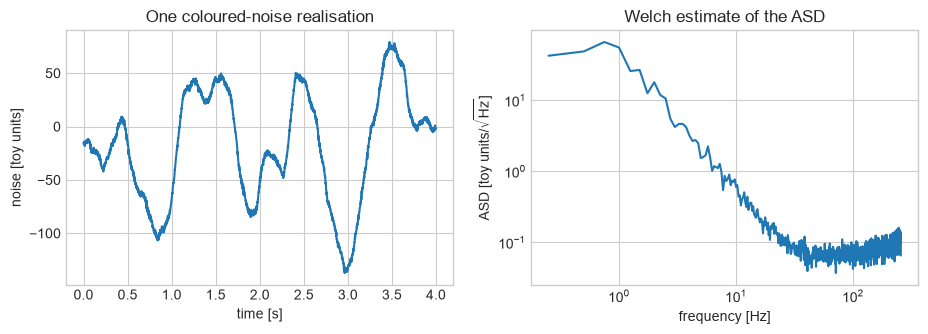

In [9]:
from scipy.signal import welch

sample_rate = 512
duration = 32
noise_time = np.arange(0, duration, 1 / sample_rate)
noise_frequency = np.fft.rfftfreq(noise_time.size, 1 / sample_rate)

# A deliberately non-white spectrum: large low-frequency noise and a mild
# high-frequency rise. The absolute normalisation is arbitrary in this toy.
noise_shape = (
    1 + (30 / np.maximum(noise_frequency, 1)) ** 4 + (noise_frequency / 180) ** 2
)
white_draw = rng.normal(size=noise_time.size)
coloured_noise = np.fft.irfft(
    np.fft.rfft(white_draw) * np.sqrt(noise_shape), n=noise_time.size
)
psd_frequency, estimated_psd = welch(
    coloured_noise,
    fs=sample_rate,
    nperseg=2048,
    average="median",
)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.3))
axes[0].plot(noise_time[: 4 * sample_rate], coloured_noise[: 4 * sample_rate])
axes[0].set(
    xlabel="time [s]",
    ylabel="noise [toy units]",
    title="One coloured-noise realisation",
)
axes[1].loglog(psd_frequency[1:], np.sqrt(estimated_psd[1:]))
axes[1].set(
    xlabel="frequency [Hz]",
    ylabel=r"ASD [toy units/$\sqrt{\mathrm{Hz}}$]",
    title="Welch estimate of the ASD",
)
plt.show()

### Optional audio analogy: hear what whitening does

This is **not detector strain converted to sound**. It is an audible toy with a
chirp buried in coloured noise. The second clip divides each Fourier component
by the known noise ASD (“whitening”), the same inverse-noise idea that appears
in the Whittle likelihood.

In [10]:
from IPython.display import Audio
from scipy.signal import chirp

audio_rate = 4096
audio_duration = 3.0
audio_time = np.arange(0, audio_duration, 1 / audio_rate)
audio_frequency = np.fft.rfftfreq(audio_time.size, 1 / audio_rate)

audio_noise_shape = 1 + (450 / np.maximum(audio_frequency, 20)) ** 4
audio_noise = np.fft.irfft(
    np.fft.rfft(rng.normal(size=audio_time.size)) * np.sqrt(audio_noise_shape),
    n=audio_time.size,
)
audio_signal = 0.8 * chirp(
    audio_time,
    f0=250,
    f1=1200,
    t1=audio_duration,
    method="quadratic",
)
audio_data = audio_noise + audio_signal

whitened_audio = np.fft.irfft(
    np.fft.rfft(audio_data) / np.sqrt(audio_noise_shape), n=audio_time.size
)


def safe_audio(values):
    values = values / np.max(np.abs(values))
    return Audio(values, rate=audio_rate, normalize=False)


print("Coloured data: the chirp is partly masked")
display(safe_audio(audio_data))
print("Whitened data: frequencies are placed on a comparable noise scale")
display(safe_audio(whitened_audio))

Coloured data: the chirp is partly masked


Whitened data: frequencies are placed on a comparable noise scale


## Checks and takeaways

1. Widen the prior: which marginal changes most?
2. Halve the assumed `sigma`: does the posterior become more accurate or merely more confident?
3. Why may the PSD-dependent likelihood normalisation be dropped for fixed-PSD
   PE but not when comparing noise models?
4. Change the prior width in the evidence cell. Why does the posterior near its
   peak barely move while the Bayes factor can change?

**Takeaway:** PE is a model–data–noise calculation. A posterior is only as trustworthy as the waveform, response, PSD, priors, and computation that define it.

Adapted from the local `nz_bilby_cbc_workshop_2024` and its source, Colm Talbot's Bayesian inference tutorial.